In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts look nicer
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
import pandas as pd

# Load
df = pd.read_csv(r'C:\Users\Harish Gudditi\Desktop\netflix_titles.csv')

# Clean NaN
df.fillna({'director': 'Unknown', 'cast': 'No Cast Info', 'country': 'Not Specified'}, inplace=True)
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

# Confirm
print('Done! Shape:', df.shape)
print(df.isnull().sum())

Done! Shape: (8790, 12)
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [3]:
# Show the first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Cast Info,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,No Cast Info,Not Specified,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# See all column names in a list
print('Column names:')
print(df.columns.tolist())

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [5]:
# Get a full summary of the dataset
df.info()

<class 'pandas.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   cast          8790 non-null   str  
 5   country       8790 non-null   str  
 6   date_added    8790 non-null   str  
 7   release_year  8790 non-null   int64
 8   rating        8790 non-null   str  
 9   duration      8790 non-null   str  
 10  listed_in     8790 non-null   str  
 11  description   8790 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.7 KB


In [6]:
# Count missing values per column
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [7]:
# Fix 1: Convert date_added from text to a real date
import pandas as pd
import matplotlib.pyplot as plt

# No need for .str.strip() — just convert directly
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year and month
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print(df[['date_added', 'year_added', 'month_added']].head())

  date_added  year_added  month_added
0 2021-09-25      2021.0          9.0
1 2021-09-24      2021.0          9.0
2 2021-09-24      2021.0          9.0
3 2021-09-24      2021.0          9.0
4 2021-09-24      2021.0          9.0


In [8]:
# Fix 2: Split duration into a number and a unit
# '90 min' → 90 and 'min'
# '3 Seasons' → 3 and 'Season'
df['duration_int']  = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'(min|Season)')

print('duration fixed!')
print(df[['title', 'type', 'duration', 'duration_int', 'duration_unit']].head(8))

duration fixed!
                              title     type   duration  duration_int  \
0              Dick Johnson Is Dead    Movie     90 min          90.0   
1                     Blood & Water  TV Show  2 Seasons           2.0   
2                         Ganglands  TV Show   1 Season           1.0   
3             Jailbirds New Orleans  TV Show   1 Season           1.0   
4                      Kota Factory  TV Show  2 Seasons           2.0   
5                     Midnight Mass  TV Show   1 Season           1.0   
6  My Little Pony: A New Generation    Movie     91 min          91.0   
7                           Sankofa    Movie    125 min         125.0   

  duration_unit  
0           min  
1        Season  
2        Season  
3        Season  
4        Season  
5        Season  
6           min  
7           min  


In [9]:
# Fix 3: Fill missing text values with 'Unknown'
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Unknown', inplace=True)

print('Missing values filled!')
print('Remaining missing values:')
print(df.isnull().sum())

Missing values filled!
Remaining missing values:
show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added       88
release_year      0
rating            0
duration          0
listed_in         0
description       0
year_added       88
month_added      88
duration_int      0
duration_unit     0
dtype: int64


C:\Users\Harish Gudditi\AppData\Local\Temp\ipykernel_15772\972218247.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'].fillna('Unknown', inplace=True)
C:\Users\Harish Gudditi\AppData\Local\Temp\ipykernel_15772\972218247.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chai

---
## Step 7 — Explore the Data (Questions & Answers)

### Question 1: How many Movies vs TV Shows are there?

In [10]:
# Count Movies and TV Shows
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


### Question 2: Which countries produce the most content?

In [11]:
# Top 10 countries
# Some titles have multiple countries (e.g. 'United States, India')
# We split them so each country is counted separately
countries = df['country'].str.split(', ').explode()
countries = countries[countries != 'Unknown']

top_countries = countries.value_counts().head(10)
print(top_countries)

country
United States     3680
India             1046
Not Specified      829
United Kingdom     803
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


### Question 3: What are the top 10 genres on Netflix?

In [12]:
# Each title can have multiple genres separated by comma
# We split them so each genre gets counted on its own
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
print(top_genres)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


### Question 4: What is the most common age rating?

In [13]:
# Count each rating category
ratings = df[df['rating'] != 'Unknown']['rating'].value_counts().head(10)
print(ratings)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


### Question 5: How many titles were added to Netflix each year?

In [14]:
# Count titles per year added
yearly = df['year_added'].value_counts().sort_index()
print(yearly)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     415
2017.0    1161
2018.0    1624
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


### Question 6: What is the average length of a Netflix movie?

In [15]:
# Filter to only Movies, then calculate average duration
movies = df[df['type'] == 'Movie']
avg_duration = movies['duration_int'].mean()
print(f'Average movie duration: {avg_duration:.0f} minutes')

# Bonus: TV Show average seasons
shows = df[df['type'] == 'TV Show']
avg_seasons = shows['duration_int'].mean()
print(f'Average TV Show length: {avg_seasons:.1f} seasons')

Average movie duration: 100 minutes
Average TV Show length: 1.8 seasons


---
## Step 8 — Visualisations (Charts)

### Chart 1 — Movies vs TV Shows (Pie Chart)

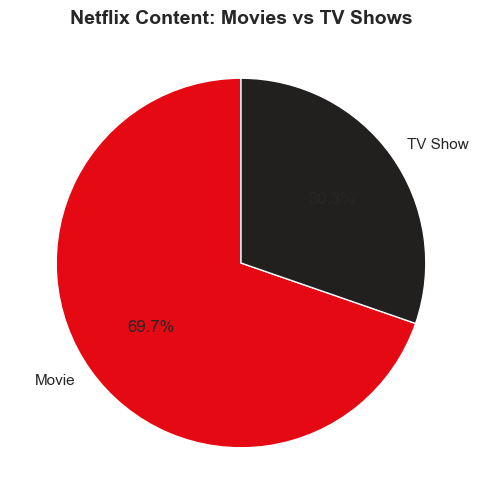

In [16]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',          # show percentages
    colors=['#E50914', '#221F1F'],
    startangle=90
)
plt.title('Netflix Content: Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.show()

### Chart 2 — Top 10 Countries (Horizontal Bar Chart)

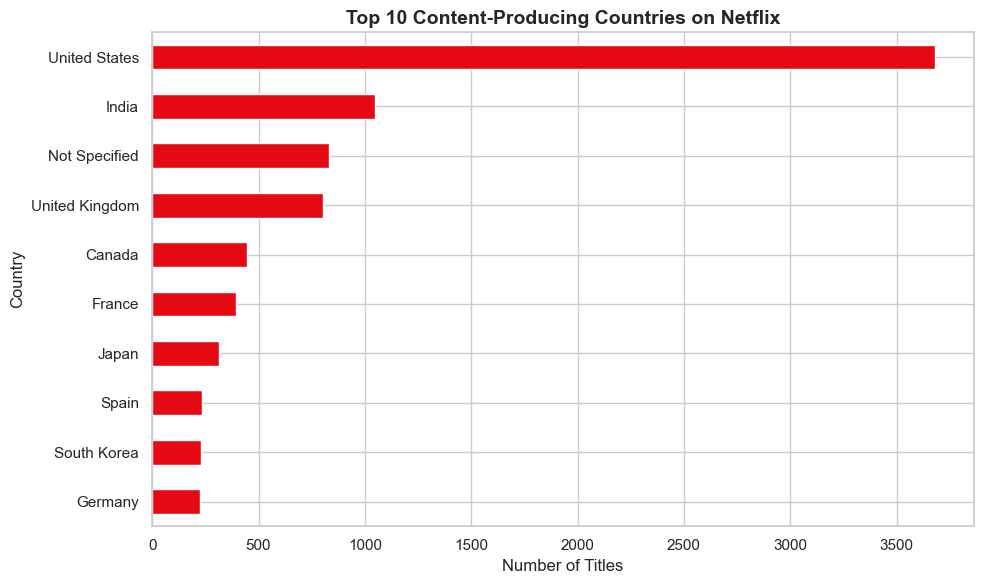

In [17]:
countries = df['country'].str.split(', ').explode()
countries = countries[countries != 'Unknown']
top_countries = countries.value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
top_countries.plot(kind='barh', color='#E50914')
plt.title('Top 10 Content-Producing Countries on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Chart 3 — Content Added to Netflix Per Year (Line Chart)

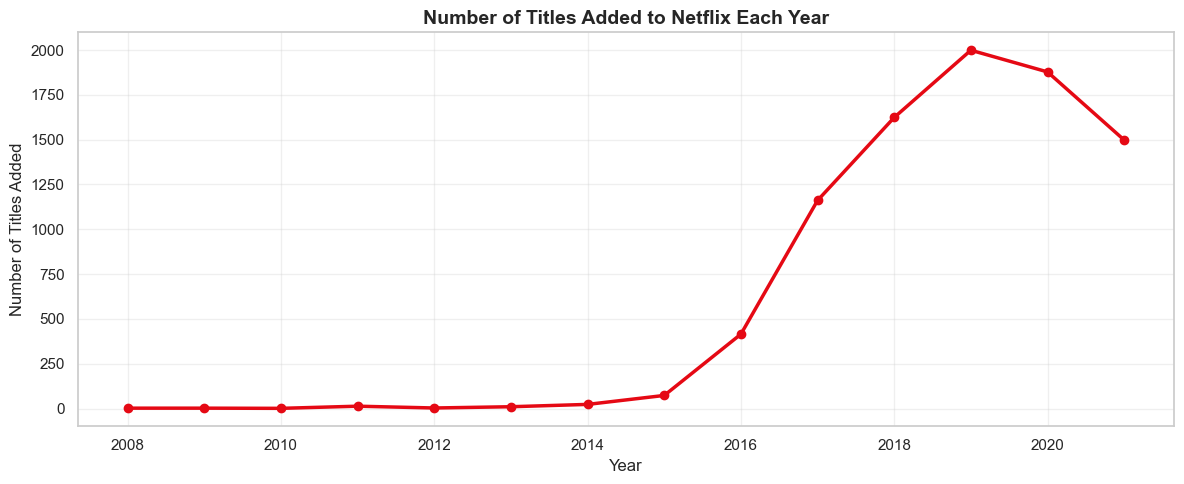

In [18]:
yearly = df['year_added'].value_counts().sort_index()
# Keep only sensible years
yearly = yearly[yearly.index >= 2008]

plt.figure(figsize=(12, 5))
plt.plot(yearly.index, yearly.values, color='#E50914', linewidth=2.5, marker='o')
plt.title('Number of Titles Added to Netflix Each Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 4 — Top 10 Genres on Netflix (Bar Chart)

C:\Users\Harish Gudditi\AppData\Local\Temp\ipykernel_15772\2383784451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')


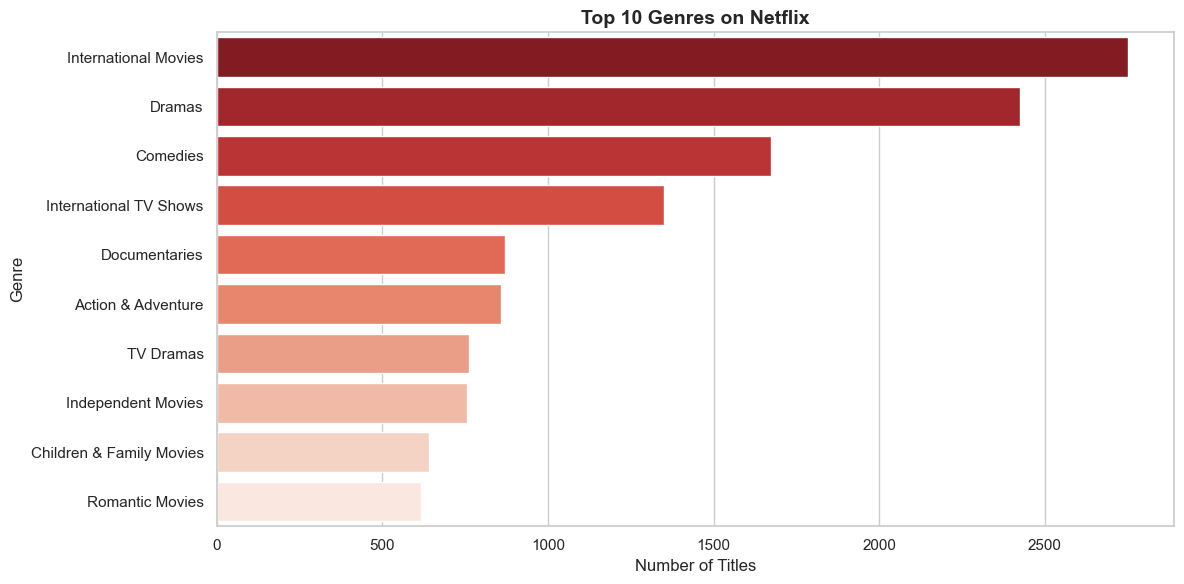

In [19]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')
plt.title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### Chart 5 — Distribution of Movie Durations (Histogram)

A histogram shows how values are spread out.  
Here it tells us: are most Netflix movies short, long, or somewhere in the middle?

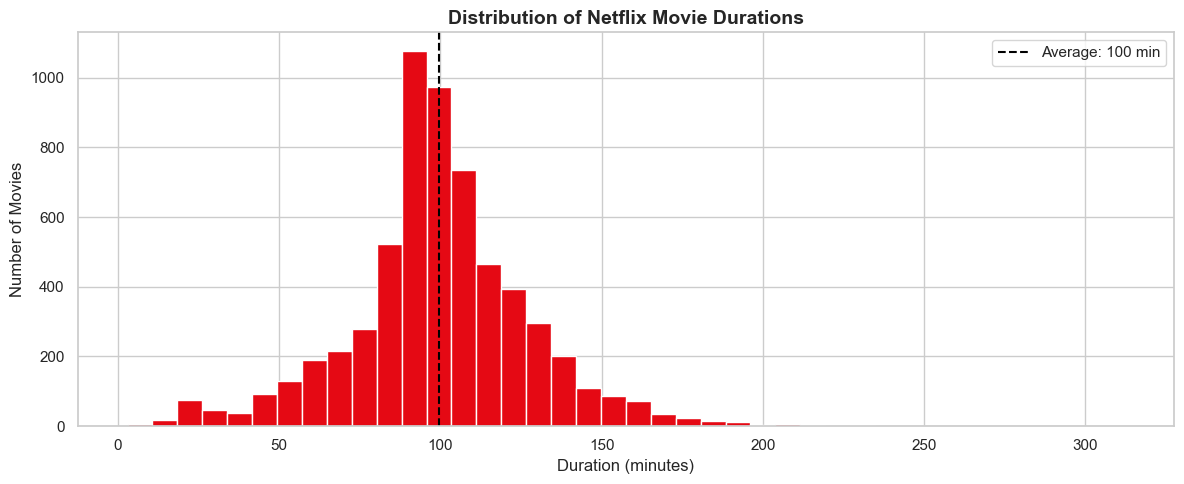

In [20]:
movies = df[df['type'] == 'Movie'].dropna(subset=['duration_int'])

plt.figure(figsize=(12, 5))
plt.hist(movies['duration_int'], bins=40, color='#E50914', edgecolor='white')
plt.title('Distribution of Netflix Movie Durations', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.axvline(movies['duration_int'].mean(), color='black', linestyle='--', label=f"Average: {movies['duration_int'].mean():.0f} min")
plt.legend()
plt.tight_layout()
plt.show()

### Chart 6 — Movies vs TV Shows Added Over Time (Stacked Area Chart)

This shows whether Netflix has been growing more Movies or TV Shows over the years.

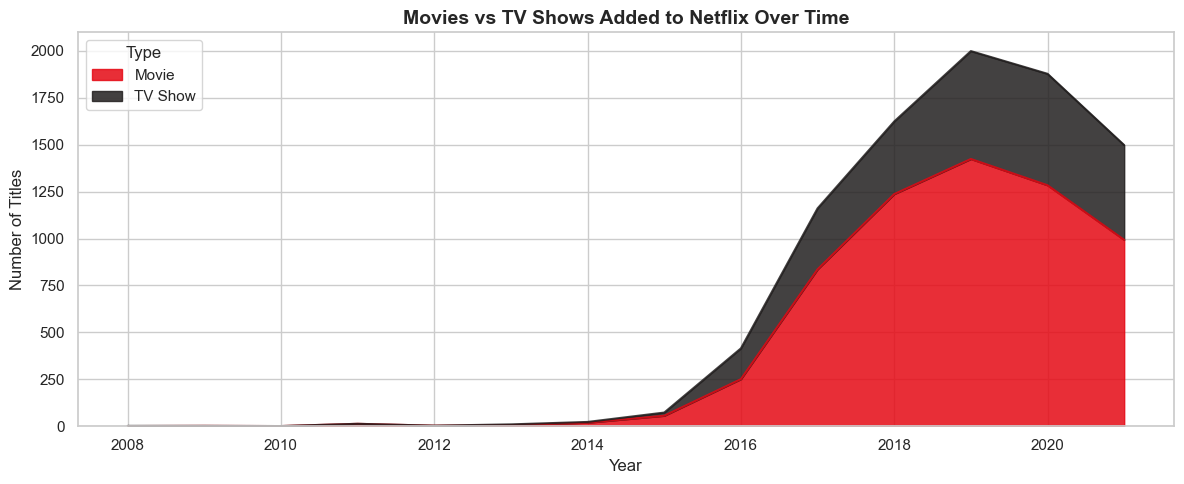

In [21]:
# Count Movies and TV Shows per year
trend = df[df['year_added'] >= 2008].groupby(['year_added', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
trend.plot(kind='area', stacked=True, color=['#E50914', '#221F1F'], alpha=0.85, ax=plt.gca())
plt.title('Movies vs TV Shows Added to Netflix Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

---
## Step 10 — Practice Exercises

Try these on your own! Each one is a small challenge using what you've learned.

### Exercise 1 — Find the top 5 most prolific directors
_(Hint: use `df['director'].value_counts().head(5)` — but exclude 'Unknown'!)_

In [22]:
import pandas as pd

# Load your dataset
df = pd.read_csv(r'C:\Users\Harish Gudditi\Desktop\netflix_titles.csv')

# Find top 5 most prolific directors (excluding 'Unknown')
top_directors = (
    df[df['director'] != 'Unknown']
    ['director']
    .value_counts()
    .head(5)
)

print("Top 5 Most Prolific Directors on Netflix:")
print("=" * 40)
for rank, (director, count) in enumerate(top_directors.items(), 1):
    print(f"{rank}. {director} — {count} titles")

Top 5 Most Prolific Directors on Netflix:
1. Rajiv Chilaka — 19 titles
2. Raúl Campos, Jan Suter — 18 titles
3. Suhas Kadav — 16 titles
4. Marcus Raboy — 16 titles
5. Jay Karas — 14 titles


### Exercise 2 — How many titles were added in each month?
_(Hint: use `df['month_added'].value_counts().sort_index()`)_

In [23]:
# Your code here
# Your code here
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['month_added'] = df['date_added'].dt.month

monthly_counts = df['month_added'].value_counts().sort_index()
print(monthly_counts)


month_added
1.0     738
2.0     563
3.0     742
4.0     764
5.0     632
6.0     728
7.0     827
8.0     755
9.0     770
10.0    760
11.0    705
12.0    813
Name: count, dtype: int64


### Exercise 3 — Make a bar chart of the top 5 ratings
_(Hint: use `df['rating'].value_counts().head(5).plot(kind='bar')`)_

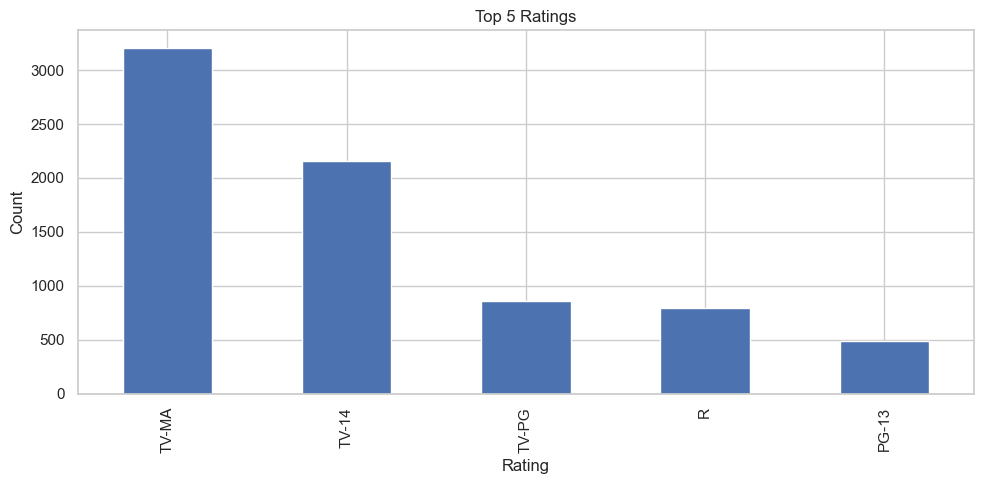

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r'C:\Users\Harish Gudditi\Desktop\netflix_titles.csv')

# Plot top 5 ratings
df['rating'].value_counts().head(5).plot(kind='bar')
plt.title('Top 5 Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Top 10 Genres by Age Group:
age_group                 Adult  Little Kids  Older Kids  Teens
genre                                                          
Action & Adventure          421            1          65    361
Children & Family Movies      1          197         409     29
Comedies                    613           61         348    633
Documentaries               348           52         187    260
Dramas                     1206           36         270    885
Independent Movies          539            3          43    154
International Movies       1233           56         308   1119
International TV Shows      715           24         137    472
Romantic Movies             205           17          95    295
TV Dramas                   435            9          49    269


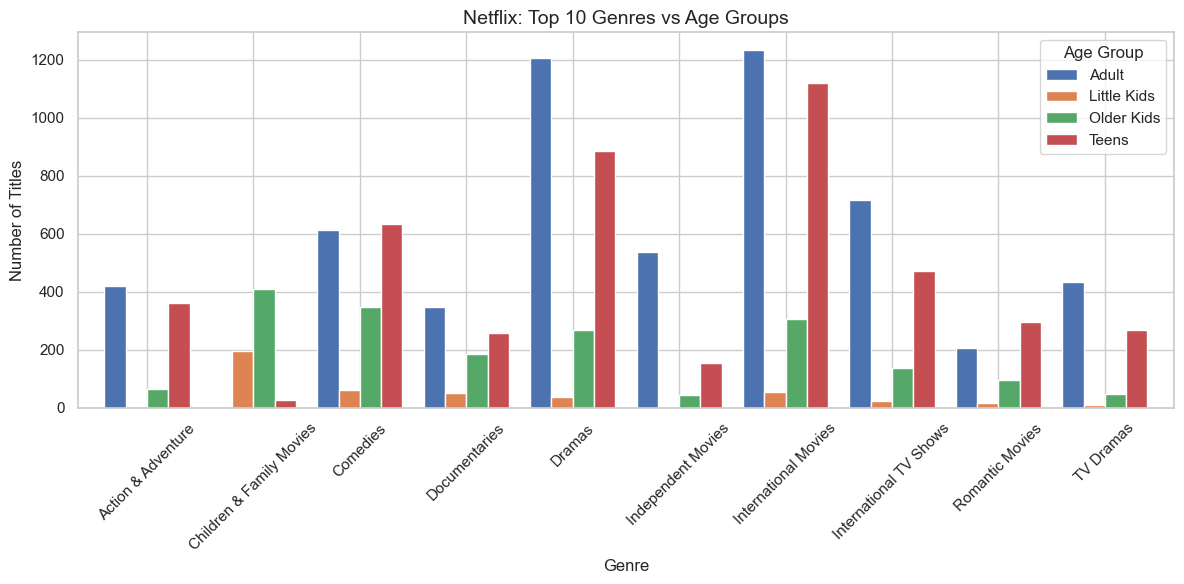

In [25]:
age_map = {
    'TV-MA': 'Adult', 'R': 'Adult', 'NC-17': 'Adult',
    'TV-14': 'Teens', 'PG-13': 'Teens',
    'TV-PG': 'Older Kids', 'PG': 'Older Kids', 'TV-Y7': 'Older Kids',
    'TV-G': 'Little Kids', 'G': 'Little Kids', 'TV-Y': 'Little Kids'
}

df['age_group'] = df['rating'].map(age_map)

df_genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')

top_genres = df_genres['genre'].value_counts().head(10).index

result = df_genres[df_genres['genre'].isin(top_genres)].groupby(['genre', 'age_group']).size().unstack().fillna(0)

print("Top 10 Genres by Age Group:")
print(result)
result.plot(kind='bar', figsize=(12, 6), width=0.8)

plt.title('Netflix: Top 10 Genres vs Age Groups', fontsize=14)
plt.ylabel('Number of Titles')
plt.xlabel('Genre')
plt.xticks(rotation=45)
plt.legend(title='Age Group')

plt.tight_layout()
plt.show()